

** Analista d'experiència del client: 

- Quins aspectes (precisió de detalls, higiene, check-in o
comunicació) presenten diferències més grans entre els allotjaments millor i pitjor valorats en
l'avaluació general?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/Users/lgm/Documents/ProjecteData/Equip_25/Data/clean_data 16-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])


** Definir grupos usando percentiles.

- Top 25% → mejores alojamientos
- Bottom 25% → peores alojamientos

In [7]:
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

In [11]:
# Cálculo de medias
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

In [10]:
difference = (top_avg - bottom_avg).sort_values(ascending=False)

diff_df = pd.DataFrame({
    "Top listings": top_avg,
    "Bottom listings": bottom_avg,
    "Difference": difference
}).round(2)

print(diff_df)

                             Top listings  Bottom listings  Difference
review_scores_accuracy              99.10            85.90       13.20
review_scores_checkin               99.12            90.25        8.87
review_scores_cleanliness           98.34            84.30       14.03
review_scores_communication         99.27            90.12        9.15


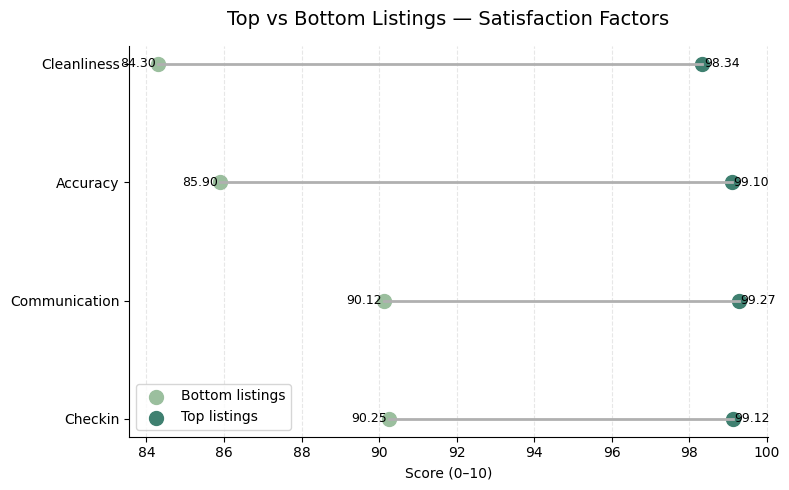

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Crear grupos
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

# 2. Variables a comparar
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

# 3. Medias
top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

# 4. DataFrame
dumbbell_df = pd.DataFrame({
    "Feature": features,
    "Top": top_avg.values,
    "Bottom": bottom_avg.values
})

# Limpiar nombres
dumbbell_df["Feature"] = dumbbell_df["Feature"].str.replace("review_scores_", "").str.capitalize()

# Ordenar por diferencia
dumbbell_df["diff"] = dumbbell_df["Top"] - dumbbell_df["Bottom"]
dumbbell_df = dumbbell_df.sort_values("diff")

# 5. Gráfico
plt.figure(figsize=(8,5))

# Líneas (dumbbell)
for i, row in dumbbell_df.iterrows():
    plt.plot(
        [row["Bottom"], row["Top"]],
        [row["Feature"], row["Feature"]],
        color="#b0b0b0",
        linewidth=2
    )

# Puntos
plt.scatter(
    dumbbell_df["Bottom"],
    dumbbell_df["Feature"],
    color="#9bbf9e",
    s=100,
    label="Bottom listings"
)

plt.scatter(
    dumbbell_df["Top"],
    dumbbell_df["Feature"],
    color="#3f8070",
    s=100,
    label="Top listings"
)

# Etiquetas valores
for i, row in dumbbell_df.iterrows():
    plt.text(row["Bottom"] - 0.05, row["Feature"], f"{row['Bottom']:.2f}", va="center", ha="right", fontsize=9)
    plt.text(row["Top"] + 0.05, row["Feature"], f"{row['Top']:.2f}", va="center", ha="left", fontsize=9)

plt.title("Top vs Bottom Listings — Satisfaction Factors", fontsize=14, pad=15)
plt.xlabel("Score (0–10)")
plt.ylabel("")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()